# **Gradient Descent Fundamentals: A Comprehensive Guide to Optimization Algorithms**

**Course:** Deep Learning and Generative AI
**Institution:** IIT Madras  
**Author:** Prof. Balaji Srinivasan
**Date:** October 2025  

---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** the mathematical foundations of gradient descent optimization
2. **Implement** Batch, Stochastic, and Mini-Batch Gradient Descent from scratch
3. **Compare** the convergence properties and computational characteristics of different gradient descent variants
4. **Analyze** the impact of learning rate and batch size on optimization performance
5. **Apply** gradient descent to solve practical machine learning problems
6. **Integrate** custom implementations with PyTorch's built-in optimizers

---

## **Prerequisites**

- Understanding of calculus (derivatives, partial derivatives, chain rule)
- Knowledge of linear algebra (vectors, matrices, matrix operations)
- Familiarity with Python and NumPy for numerical computing
- Basic understanding of machine learning concepts
- Understanding of loss functions and their role in optimization

## **1. Introduction to Optimization and Gradient Descent**

### **1.1 The Optimization Problem**

**Machine learning fundamentally involves solving optimization problems.** Given a model with parameters **θ**, a dataset **D = {(x₁, y₁), (x₂, y₂), ..., (xₙ, yₙ)}**, and a loss function **L(θ)**, our goal is to find the optimal parameters that minimize the loss.

### **1.2 Gradient Descent: The Foundation**

**Gradient descent is an iterative optimization algorithm that uses the gradient (first-order derivative) of the loss function to find local minima.** The algorithm is based on a simple intuition: to minimize a function, move in the direction of steepest descent.

#### **1.2.1 Mathematical Formulation**

The gradient descent update rule is:

**θₜ₊₁ = θₜ - η$∇_θ$L(θₜ)**

Where:
- **θₜ**: Parameters at iteration t
- **θₜ₊₁**: Updated parameters at iteration t+1
- **η**: Learning rate (step size) - a hyperparameter controlling the magnitude of updates
- **$∇_θ$L(θₜ)**: Gradient of the loss function with respect to parameters at θₜ

#### **1.2.2 Geometric Interpretation**

The gradient **$∇_θ$L(θₜ)** points in the direction of **steepest ascent**. By moving in the negative gradient direction (-$∇_θ$L(θₜ)), we move toward lower loss values, eventually reaching a local minimum.

#### **1.2.3 Key Properties**

| **Property** | **Description** | **Implication** |
|--------------|-----------------|----------------|
| **First-Order Method** | Uses only first derivatives (gradients) | Computationally efficient, widely applicable |
| **Iterative** | Updates parameters step-by-step | Allows monitoring and early stopping |
| **Local Optimization** | Converges to local minima, not necessarily global | Initial parameters and learning rate matter |
| **Scalable** | Works with large datasets and high dimensions | Foundation for deep learning optimization |

### **1.3 Types of Gradient Descent**

**The primary distinction between gradient descent variants lies in how many training samples are used to compute the gradient at each iteration.** This fundamental choice creates a trade-off between computational efficiency and gradient accuracy.

## **2. Experimental Setup and Data Preparation**

### **2.1 Problem Formulation**

**We will implement and compare gradient descent variants using a linear regression problem.** This controlled experimental setup allows us to:

1. **Validate implementations**: Compare with known analytical solutions
2. **Visualize convergence**: Observe optimization trajectories in 2D parameter space
3. **Analyze trade-offs**: Understand computational vs. statistical efficiency

**Mathematical Model:**

**y = w·x + b + ε**

Where:
- **w = 3.5**: True weight parameter (slope)
- **b = 2.0**: True bias parameter (intercept)
- **ε ~ N(0, σ²)**: Gaussian noise with standard deviation σ = 1.0

**Loss Function (Mean Squared Error):**

**L(w, b) = (1/n) Σᵢ₌₁ⁿ (yᵢ - (w·xᵢ + b))²**

**Gradients:**

**∂L/∂w = (2/n) Σᵢ₌₁ⁿ (w·xᵢ + b - yᵢ)·xᵢ**

**∂L/∂b = (2/n) Σᵢ₌₁ⁿ (w·xᵢ + b - yᵢ)**

In [1]:
# Import essential libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import time
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for high-quality visualizations
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

print("Environment Setup Complete")
print("=" * 50)
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Backend: {plt.get_backend()}")
print(f"Random Seed: 42")
print("=" * 50)

Environment Setup Complete
NumPy Version: 2.0.2
Matplotlib Backend: module://matplotlib_inline.backend_inline
Random Seed: 42


In [2]:
# Generate synthetic dataset for linear regression

# Define ground truth parameters
TRUE_WEIGHT = 3.5
TRUE_BIAS = 2.0
NOISE_STD = 1.0

# Dataset configuration
N_SAMPLES = 1000
X_MIN, X_MAX = 0, 5

# Generate features uniformly distributed in [X_MIN, X_MAX]
X = np.random.uniform(X_MIN, X_MAX, N_SAMPLES)

# Generate targets using true linear relationship with Gaussian noise
y = TRUE_WEIGHT * X + TRUE_BIAS + np.random.normal(0, NOISE_STD, N_SAMPLES)

# Reshape for matrix operations (column vectors)
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

print("Dataset Generation Summary")
print("=" * 50)
print(f"Number of Samples: {N_SAMPLES}")
print(f"Feature Range: [{X.min():.2f}, {X.max():.2f}]")
print(f"Target Range: [{y.min():.2f}, {y.max():.2f}]")
print(f"\nGround Truth Parameters:")
print(f"  Weight (w): {TRUE_WEIGHT}")
print(f"  Bias (b): {TRUE_BIAS}")
print(f"  Noise Std (σ): {NOISE_STD}")
print(f"\nData Shapes:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print("=" * 50)

Dataset Generation Summary
Number of Samples: 1000
Feature Range: [0.02, 5.00]
Target Range: [0.17, 21.15]

Ground Truth Parameters:
  Weight (w): 3.5
  Bias (b): 2.0
  Noise Std (σ): 1.0

Data Shapes:
  X: (1000, 1)
  y: (1000, 1)


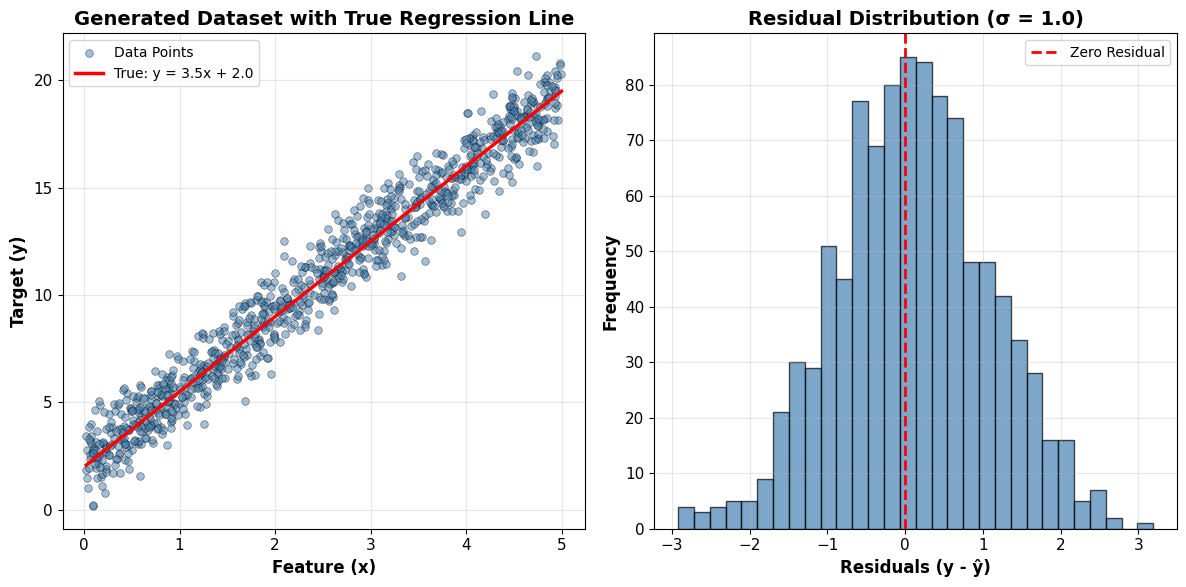

Residual Statistics:
  Mean: 0.0989 (should be ≈ 0)
  Std Dev: 0.9884 (should be ≈ 1.0)


In [3]:
# Visualize the generated dataset

plt.figure(figsize=(12, 6))

# Plot 1: Scatter plot with true regression line
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5, s=30, c='steelblue', edgecolors='black', linewidth=0.5, label='Data Points')

# Plot true regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_line = TRUE_WEIGHT * x_line + TRUE_BIAS
plt.plot(x_line, y_line, 'r-', linewidth=2.5, label=f'True: y = {TRUE_WEIGHT}x + {TRUE_BIAS}')

plt.xlabel('Feature (x)', fontweight='bold')
plt.ylabel('Target (y)', fontweight='bold')
plt.title('Generated Dataset with True Regression Line', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual distribution
plt.subplot(1, 2, 2)
residuals = y.flatten() - (TRUE_WEIGHT * X.flatten() + TRUE_BIAS)
plt.hist(residuals, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
plt.xlabel('Residuals (y - ŷ)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title(f'Residual Distribution (σ = {NOISE_STD})', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"  Mean: {np.mean(residuals):.4f} (should be ≈ 0)")
print(f"  Std Dev: {np.std(residuals):.4f} (should be ≈ {NOISE_STD})")

## **3. Core Gradient Descent Implementations**

### **3.1 Utility Functions**

Before implementing the gradient descent variants, we define utility functions for:
1. **Loss computation**: Measuring prediction error
2. **Gradient calculation**: Computing derivatives with respect to parameters
3. **Prediction**: Generating outputs from the model

In [4]:
def compute_loss(X: np.ndarray, y: np.ndarray, w: float, b: float) -> float:
    """
    Compute Mean Squared Error (MSE) loss.

    Mathematical Definition:
    L(w, b) = (1/n) * Σᵢ₌₁ⁿ (yᵢ - (w·xᵢ + b))²

    Parameters:
    -----------
    X : np.ndarray
        Feature matrix with shape (n_samples, 1)
    y : np.ndarray
        Target vector with shape (n_samples, 1)
    w : float
        Weight parameter
    b : float
        Bias parameter

    Returns:
    --------
    float
        Mean squared error loss
    """
    n = len(X)
    predictions = w * X + b
    loss = np.sum((y - predictions) ** 2) / n
    return loss


def compute_gradients(X: np.ndarray, y: np.ndarray, w: float, b: float) -> Tuple[float, float]:
    """
    Compute gradients of MSE loss with respect to parameters.

    Mathematical Definitions:
    ∂L/∂w = (2/n) * Σᵢ₌₁ⁿ (w·xᵢ + b - yᵢ) · xᵢ
    ∂L/∂b = (2/n) * Σᵢ₌₁ⁿ (w·xᵢ + b - yᵢ)

    Parameters:
    -----------
    X : np.ndarray
        Feature matrix with shape (n_samples, 1)
    y : np.ndarray
        Target vector with shape (n_samples, 1)
    w : float
        Weight parameter
    b : float
        Bias parameter

    Returns:
    --------
    Tuple[float, float]
        Gradients (dw, db) with respect to weight and bias
    """
    n = len(X)
    predictions = w * X + b
    errors = predictions - y

    # Compute gradients
    dw = (2 / n) * np.sum(errors * X)
    db = (2 / n) * np.sum(errors)

    return dw, db


def predict(X: np.ndarray, w: float, b: float) -> np.ndarray:
    """
    Generate predictions using linear model.

    Parameters:
    -----------
    X : np.ndarray
        Feature matrix
    w : float
        Weight parameter
    b : float
        Bias parameter

    Returns:
    --------
    np.ndarray
        Predictions with same shape as X
    """
    return w * X + b


# Test utility functions
test_w, test_b = 1.0, 0.5
test_loss = compute_loss(X[:10], y[:10], test_w, test_b)
test_dw, test_db = compute_gradients(X[:10], y[:10], test_w, test_b)
test_pred = predict(X[:5], test_w, test_b)

print("Utility Functions Test:")
print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Gradients: dw = {test_dw:.4f}, db = {test_db:.4f}")
print(f"Test Predictions (first 5): {test_pred.flatten()[:5]}")
print("✓ All utility functions working correctly")
print("=" * 50)

Utility Functions Test:
Test Loss: 76.4285
Test Gradients: dw = -51.7688, db = -16.2106
Test Predictions (first 5): [2.37270059 5.25357153 4.15996971 3.49329242 1.2800932 ]
✓ All utility functions working correctly


### **3.2 Batch Gradient Descent (BGD)**

**Batch Gradient Descent uses the entire dataset to compute gradients at each iteration.** This provides the most accurate gradient estimate but is computationally expensive for large datasets.

#### **3.2.1 Algorithm**

```
Initialize: w, b randomly
For each epoch:
    1. Compute predictions for ALL samples: ŷ = w·X + b
    2. Compute loss: L = (1/n)Σ(y - ŷ)²
    3. Compute gradients using ALL samples:
       dw = (2/n)Σ(ŷ - y)·X
       db = (2/n)Σ(ŷ - y)
    4. Update parameters:
       w = w - η·dw
       b = b - η·db
```

#### **3.2.2 Characteristics**

| **Aspect** | **Description** |
|------------|----------------|
| **Gradient Quality** | Exact gradient of full loss function |
| **Convergence** | Smooth, deterministic path to local minimum |
| **Computation** | O(n·d) per iteration - expensive for large n |
| **Memory** | Requires loading entire dataset |
| **Updates per Epoch** | 1 update per complete pass through data |

In [5]:
def batch_gradient_descent(X: np.ndarray, y: np.ndarray, learning_rate: float = 0.01,
                          epochs: int = 100, initial_w: float = 0.0, initial_b: float = 0.0,
                          verbose: bool = True) -> Dict:
    """
    Implement Batch Gradient Descent optimization.

    Uses entire dataset for each gradient computation, providing accurate but
    computationally expensive updates.

    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y : np.ndarray
        Target vector (n_samples, 1)
    learning_rate : float
        Step size for parameter updates (η)
    epochs : int
        Number of complete passes through the dataset
    initial_w : float
        Initial weight parameter
    initial_b : float
        Initial bias parameter
    verbose : bool
        Whether to print progress information

    Returns:
    --------
    Dict
        Dictionary containing:
        - 'w': final weight
        - 'b': final bias
        - 'loss_history': loss at each epoch
        - 'w_history': weight values over training
        - 'b_history': bias values over training
        - 'time': total training time
    """
    # Initialize parameters
    w = initial_w
    b = initial_b
    n = len(X)

    # Tracking variables
    loss_history = []
    w_history = [w]
    b_history = [b]

    # Start timer
    start_time = time.time()

    if verbose:
        print("Batch Gradient Descent Training")
        print("=" * 60)
        print(f"Dataset Size: {n} samples")
        print(f"Learning Rate: {learning_rate}")
        print(f"Epochs: {epochs}")
        print("=" * 60)

    # Training loop
    for epoch in range(epochs):
        # Compute gradients using ENTIRE dataset
        dw, db = compute_gradients(X, y, w, b)

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Compute and store loss
        loss = compute_loss(X, y, w, b)
        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)

        # Print progress
        if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {w:.4f} | b: {b:.4f}")

    training_time = time.time() - start_time

    if verbose:
        print("=" * 60)
        print(f"Training completed in {training_time:.4f} seconds")
        print(f"Final Parameters: w = {w:.4f}, b = {b:.4f}")
        print(f"Final Loss: {loss_history[-1]:.6f}")

    return {
        'w': w,
        'b': b,
        'loss_history': loss_history,
        'w_history': w_history,
        'b_history': b_history,
        'time': training_time,
        'method': 'Batch GD'
    }


# Train model using Batch Gradient Descent
bgd_results = batch_gradient_descent(
    X, y,
    learning_rate=0.01,
    epochs=100,
    initial_w=0.0,
    initial_b=0.0,
    verbose=True
)

print(f"\n{'='*60}")
print(f"Parameter Recovery Analysis:")
print(f"  True Weight: {TRUE_WEIGHT:.4f} | Learned: {bgd_results['w']:.4f} | Error: {abs(TRUE_WEIGHT - bgd_results['w']):.4f}")
print(f"  True Bias: {TRUE_BIAS:.4f} | Learned: {bgd_results['b']:.4f} | Error: {abs(TRUE_BIAS - bgd_results['b']):.4f}")
print(f"{'='*60}")

Batch Gradient Descent Training
Dataset Size: 1000 samples
Learning Rate: 0.01
Epochs: 100
Epoch    0 | Loss: 95.432916 | w: 0.6714 | b: 0.2136
Epoch   10 | Loss: 3.079830 | w: 3.3264 | b: 1.0886
Epoch   20 | Loss: 1.227453 | w: 3.6885 | b: 1.2497
Epoch   30 | Loss: 1.171430 | w: 3.7283 | b: 1.3086
Epoch   40 | Loss: 1.152791 | w: 3.7232 | b: 1.3514
Epoch   50 | Loss: 1.136498 | w: 3.7122 | b: 1.3903
Epoch   60 | Loss: 1.121709 | w: 3.7010 | b: 1.4271
Epoch   70 | Loss: 1.108275 | w: 3.6901 | b: 1.4622
Epoch   80 | Loss: 1.096070 | w: 3.6798 | b: 1.4956
Epoch   90 | Loss: 1.084983 | w: 3.6699 | b: 1.5274
Epoch   99 | Loss: 1.075875 | w: 3.6614 | b: 1.5548
Training completed in 0.0048 seconds
Final Parameters: w = 3.6614, b = 1.5548
Final Loss: 1.075875

Parameter Recovery Analysis:
  True Weight: 3.5000 | Learned: 3.6614 | Error: 0.1614
  True Bias: 2.0000 | Learned: 1.5548 | Error: 0.4452


### **3.3 Stochastic Gradient Descent (SGD)**

**Stochastic Gradient Descent uses a single randomly selected sample to compute gradients at each iteration.** This provides fast updates with noisy gradients, enabling online learning and escape from poor local minima.

#### **3.3.1 Algorithm**

```
Initialize: w, b randomly
For each epoch:
    Shuffle dataset
    For each sample (xᵢ, yᵢ):
        1. Compute prediction: ŷᵢ = w·xᵢ + b
        2. Compute loss for single sample: L = (yᵢ - ŷᵢ)²
        3. Compute gradients using single sample:
           dw = 2·(ŷᵢ - yᵢ)·xᵢ
           db = 2·(ŷᵢ - yᵢ)
        4. Update parameters immediately:
           w = w - η·dw
           b = b - η·db
```

#### **3.3.2 Characteristics**

| **Aspect** | **Description** |
|------------|----------------|
| **Gradient Quality** | Noisy approximation of true gradient |
| **Convergence** | Fluctuating path, may not converge to exact minimum |
| **Computation** | O(d) per iteration - very fast |
| **Memory** | Minimal - processes one sample at a time |
| **Updates per Epoch** | n updates (one per sample) |
| **Special Properties** | Can escape shallow local minima, enables online learning |

In [6]:
def stochastic_gradient_descent(X: np.ndarray, y: np.ndarray, learning_rate: float = 0.01,
                               epochs: int = 100, initial_w: float = 0.0, initial_b: float = 0.0,
                               verbose: bool = True, log_interval: int = 100) -> Dict:
    """
    Implement Stochastic Gradient Descent optimization.

    Uses single random sample for each gradient computation, providing fast but
    noisy updates.

    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y : np.ndarray
        Target vector (n_samples, 1)
    learning_rate : float
        Step size for parameter updates (η)
    epochs : int
        Number of complete passes through the dataset
    initial_w : float
        Initial weight parameter
    initial_b : float
        Initial bias parameter
    verbose : bool
        Whether to print progress information
    log_interval : int
        Number of iterations between loss calculations

    Returns:
    --------
    Dict
        Dictionary containing training results and history
    """
    # Initialize parameters
    w = initial_w
    b = initial_b
    n = len(X)

    # Tracking variables
    loss_history = []
    w_history = [w]
    b_history = [b]
    iteration_count = 0

    # Start timer
    start_time = time.time()

    if verbose:
        print("Stochastic Gradient Descent Training")
        print("=" * 60)
        print(f"Dataset Size: {n} samples")
        print(f"Learning Rate: {learning_rate}")
        print(f"Epochs: {epochs}")
        print(f"Updates per Epoch: {n}")
        print(f"Total Updates: {epochs * n}")
        print("=" * 60)

    # Training loop
    for epoch in range(epochs):
        # Shuffle data for each epoch
        indices = np.random.permutation(n)

        # Process each sample individually
        for i in indices:
            # Extract single sample
            xi = X[i:i+1]
            yi = y[i:i+1]

            # Compute gradients using SINGLE sample
            dw, db = compute_gradients(xi, yi, w, b)

            # Update parameters immediately
            w = w - learning_rate * dw
            b = b - learning_rate * db

            iteration_count += 1

            # Periodically compute and store loss on full dataset
            if iteration_count % log_interval == 0:
                loss = compute_loss(X, y, w, b)
                loss_history.append(loss)
                w_history.append(w)
                b_history.append(b)

        # Compute epoch-end loss
        loss = compute_loss(X, y, w, b)
        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)

        # Print progress
        if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {w:.4f} | b: {b:.4f}")

    training_time = time.time() - start_time

    if verbose:
        print("=" * 60)
        print(f"Training completed in {training_time:.4f} seconds")
        print(f"Final Parameters: w = {w:.4f}, b = {b:.4f}")
        print(f"Final Loss: {loss_history[-1]:.6f}")
        print(f"Total Parameter Updates: {iteration_count}")

    return {
        'w': w,
        'b': b,
        'loss_history': loss_history,
        'w_history': w_history,
        'b_history': b_history,
        'time': training_time,
        'iterations': iteration_count,
        'method': 'Stochastic GD'
    }


# Train model using Stochastic Gradient Descent
sgd_results = stochastic_gradient_descent(
    X, y,
    learning_rate=0.001,  # Note: typically needs smaller learning rate than BGD
    epochs=20,  # Fewer epochs needed due to many updates per epoch
    initial_w=0.0,
    initial_b=0.0,
    verbose=True,
    log_interval=200
)

print(f"\n{'='*60}")
print(f"Parameter Recovery Analysis:")
print(f"  True Weight: {TRUE_WEIGHT:.4f} | Learned: {sgd_results['w']:.4f} | Error: {abs(TRUE_WEIGHT - sgd_results['w']):.4f}")
print(f"  True Bias: {TRUE_BIAS:.4f} | Learned: {sgd_results['b']:.4f} | Error: {abs(TRUE_BIAS - sgd_results['b']):.4f}")
print(f"{'='*60}")

Stochastic Gradient Descent Training
Dataset Size: 1000 samples
Learning Rate: 0.001
Epochs: 20
Updates per Epoch: 1000
Total Updates: 20000
Epoch    0 | Loss: 1.086612 | w: 3.6362 | b: 1.5368
Epoch    2 | Loss: 0.992210 | w: 3.5583 | b: 1.9397
Epoch    4 | Loss: 0.980320 | w: 3.4798 | b: 2.0770
Epoch    6 | Loss: 0.976953 | w: 3.4939 | b: 2.1397
Epoch    8 | Loss: 0.975232 | w: 3.4695 | b: 2.1575
Epoch   10 | Loss: 0.975375 | w: 3.4657 | b: 2.1633
Epoch   12 | Loss: 0.988287 | w: 3.5061 | b: 2.1859
Epoch   14 | Loss: 0.988218 | w: 3.5072 | b: 2.1819
Epoch   16 | Loss: 0.997983 | w: 3.4206 | b: 2.1593
Epoch   18 | Loss: 0.974975 | w: 3.4708 | b: 2.1718
Epoch   19 | Loss: 0.976589 | w: 3.4823 | b: 2.1776
Training completed in 0.4174 seconds
Final Parameters: w = 3.4823, b = 2.1776
Final Loss: 0.976589
Total Parameter Updates: 20000

Parameter Recovery Analysis:
  True Weight: 3.5000 | Learned: 3.4823 | Error: 0.0177
  True Bias: 2.0000 | Learned: 2.1776 | Error: 0.1776


### **3.4 Mini-Batch Gradient Descent (MBGD)**

**Mini-Batch Gradient Descent uses small batches of samples to compute gradients.** This balances the accuracy of BGD with the speed of SGD, and is the most commonly used variant in modern deep learning.

#### **3.4.1 Algorithm**

```
Initialize: w, b randomly
For each epoch:
    Shuffle dataset
    Divide dataset into batches of size b
    For each batch B:
        1. Compute predictions for batch: ŷ = w·X_batch + b
        2. Compute loss for batch: L = (1/b)Σ(y_batch - ŷ)²
        3. Compute gradients using batch:
           dw = (2/b)Σ(ŷ - y_batch)·X_batch
           db = (2/b)Σ(ŷ - y_batch)
        4. Update parameters:
           w = w - η·dw
           b = b - η·db
```

#### **3.4.2 Characteristics**

| **Aspect** | **Description** |
|------------|----------------|
| **Gradient Quality** | Smoothed approximation, better than SGD |
| **Convergence** | Moderately smooth, good balance |
| **Computation** | O(b·d) per iteration - efficient and parallelizable |
| **Memory** | Moderate - processes one batch at a time |
| **Updates per Epoch** | n/b updates |
| **Special Properties** | GPU-friendly, best practice for deep learning |

#### **3.4.3 Batch Size Selection**

Common batch sizes: 32, 64, 128, 256
- **Small batches** (16-32): More noise, better generalization, memory efficient
- **Large batches** (256-512): Smoother convergence, faster computation, more memory

In [7]:
def mini_batch_gradient_descent(X: np.ndarray, y: np.ndarray, learning_rate: float = 0.01,
                               epochs: int = 100, batch_size: int = 32,
                               initial_w: float = 0.0, initial_b: float = 0.0,
                               verbose: bool = True) -> Dict:
    """
    Implement Mini-Batch Gradient Descent optimization.

    Uses small batches of samples for gradient computation, balancing accuracy
    and computational efficiency.

    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y : np.ndarray
        Target vector (n_samples, 1)
    learning_rate : float
        Step size for parameter updates (η)
    epochs : int
        Number of complete passes through the dataset
    batch_size : int
        Number of samples per batch
    initial_w : float
        Initial weight parameter
    initial_b : float
        Initial bias parameter
    verbose : bool
        Whether to print progress information

    Returns:
    --------
    Dict
        Dictionary containing training results and history
    """
    # Initialize parameters
    w = initial_w
    b = initial_b
    n = len(X)
    n_batches = int(np.ceil(n / batch_size))

    # Tracking variables
    loss_history = []
    w_history = [w]
    b_history = [b]
    iteration_count = 0

    # Start timer
    start_time = time.time()

    if verbose:
        print("Mini-Batch Gradient Descent Training")
        print("=" * 60)
        print(f"Dataset Size: {n} samples")
        print(f"Batch Size: {batch_size}")
        print(f"Number of Batches: {n_batches}")
        print(f"Learning Rate: {learning_rate}")
        print(f"Epochs: {epochs}")
        print(f"Updates per Epoch: {n_batches}")
        print("=" * 60)

    # Training loop
    for epoch in range(epochs):
        # Shuffle data for each epoch
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Process each mini-batch
        for batch_idx in range(n_batches):
            # Extract mini-batch
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n)

            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            # Compute gradients using MINI-BATCH
            dw, db = compute_gradients(X_batch, y_batch, w, b)

            # Update parameters
            w = w - learning_rate * dw
            b = b - learning_rate * db

            iteration_count += 1

        # Compute epoch-end loss on full dataset
        loss = compute_loss(X, y, w, b)
        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)

        # Print progress
        if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {w:.4f} | b: {b:.4f}")

    training_time = time.time() - start_time

    if verbose:
        print("=" * 60)
        print(f"Training completed in {training_time:.4f} seconds")
        print(f"Final Parameters: w = {w:.4f}, b = {b:.4f}")
        print(f"Final Loss: {loss_history[-1]:.6f}")
        print(f"Total Parameter Updates: {iteration_count}")

    return {
        'w': w,
        'b': b,
        'loss_history': loss_history,
        'w_history': w_history,
        'b_history': b_history,
        'time': training_time,
        'iterations': iteration_count,
        'batch_size': batch_size,
        'method': 'Mini-Batch GD'
    }


# Train model using Mini-Batch Gradient Descent
mbgd_results = mini_batch_gradient_descent(
    X, y,
    learning_rate=0.01,
    epochs=50,
    batch_size=32,
    initial_w=0.0,
    initial_b=0.0,
    verbose=True
)

print(f"\n{'='*60}")
print(f"Parameter Recovery Analysis:")
print(f"  True Weight: {TRUE_WEIGHT:.4f} | Learned: {mbgd_results['w']:.4f} | Error: {abs(TRUE_WEIGHT - mbgd_results['w']):.4f}")
print(f"  True Bias: {TRUE_BIAS:.4f} | Learned: {mbgd_results['b']:.4f} | Error: {abs(TRUE_BIAS - mbgd_results['b']):.4f}")
print(f"{'='*60}")

Mini-Batch Gradient Descent Training
Dataset Size: 1000 samples
Batch Size: 32
Number of Batches: 32
Learning Rate: 0.01
Epochs: 50
Updates per Epoch: 32
Epoch    0 | Loss: 1.169412 | w: 3.7498 | b: 1.3240
Epoch    5 | Loss: 1.018246 | w: 3.5789 | b: 1.7730
Epoch   10 | Loss: 0.983690 | w: 3.5214 | b: 1.9928
Epoch   15 | Loss: 0.986851 | w: 3.5270 | b: 2.1014
Epoch   20 | Loss: 0.982313 | w: 3.5059 | b: 2.1511
Epoch   25 | Loss: 0.988856 | w: 3.4350 | b: 2.1513
Epoch   30 | Loss: 0.976893 | w: 3.4583 | b: 2.1601
Epoch   35 | Loss: 0.975494 | w: 3.4798 | b: 2.1653
Epoch   40 | Loss: 0.981956 | w: 3.4977 | b: 2.1769
Epoch   45 | Loss: 0.982243 | w: 3.4436 | b: 2.1603
Epoch   49 | Loss: 0.975608 | w: 3.4634 | b: 2.1648
Training completed in 0.0381 seconds
Final Parameters: w = 3.4634, b = 2.1648
Final Loss: 0.975608
Total Parameter Updates: 1600

Parameter Recovery Analysis:
  True Weight: 3.5000 | Learned: 3.4634 | Error: 0.0366
  True Bias: 2.0000 | Learned: 2.1648 | Error: 0.1648


## **4. Comprehensive Comparison and Analysis**

### **4.1 Convergence Comparison**

**Visualizing the loss curves reveals the distinct convergence patterns of each gradient descent variant.**

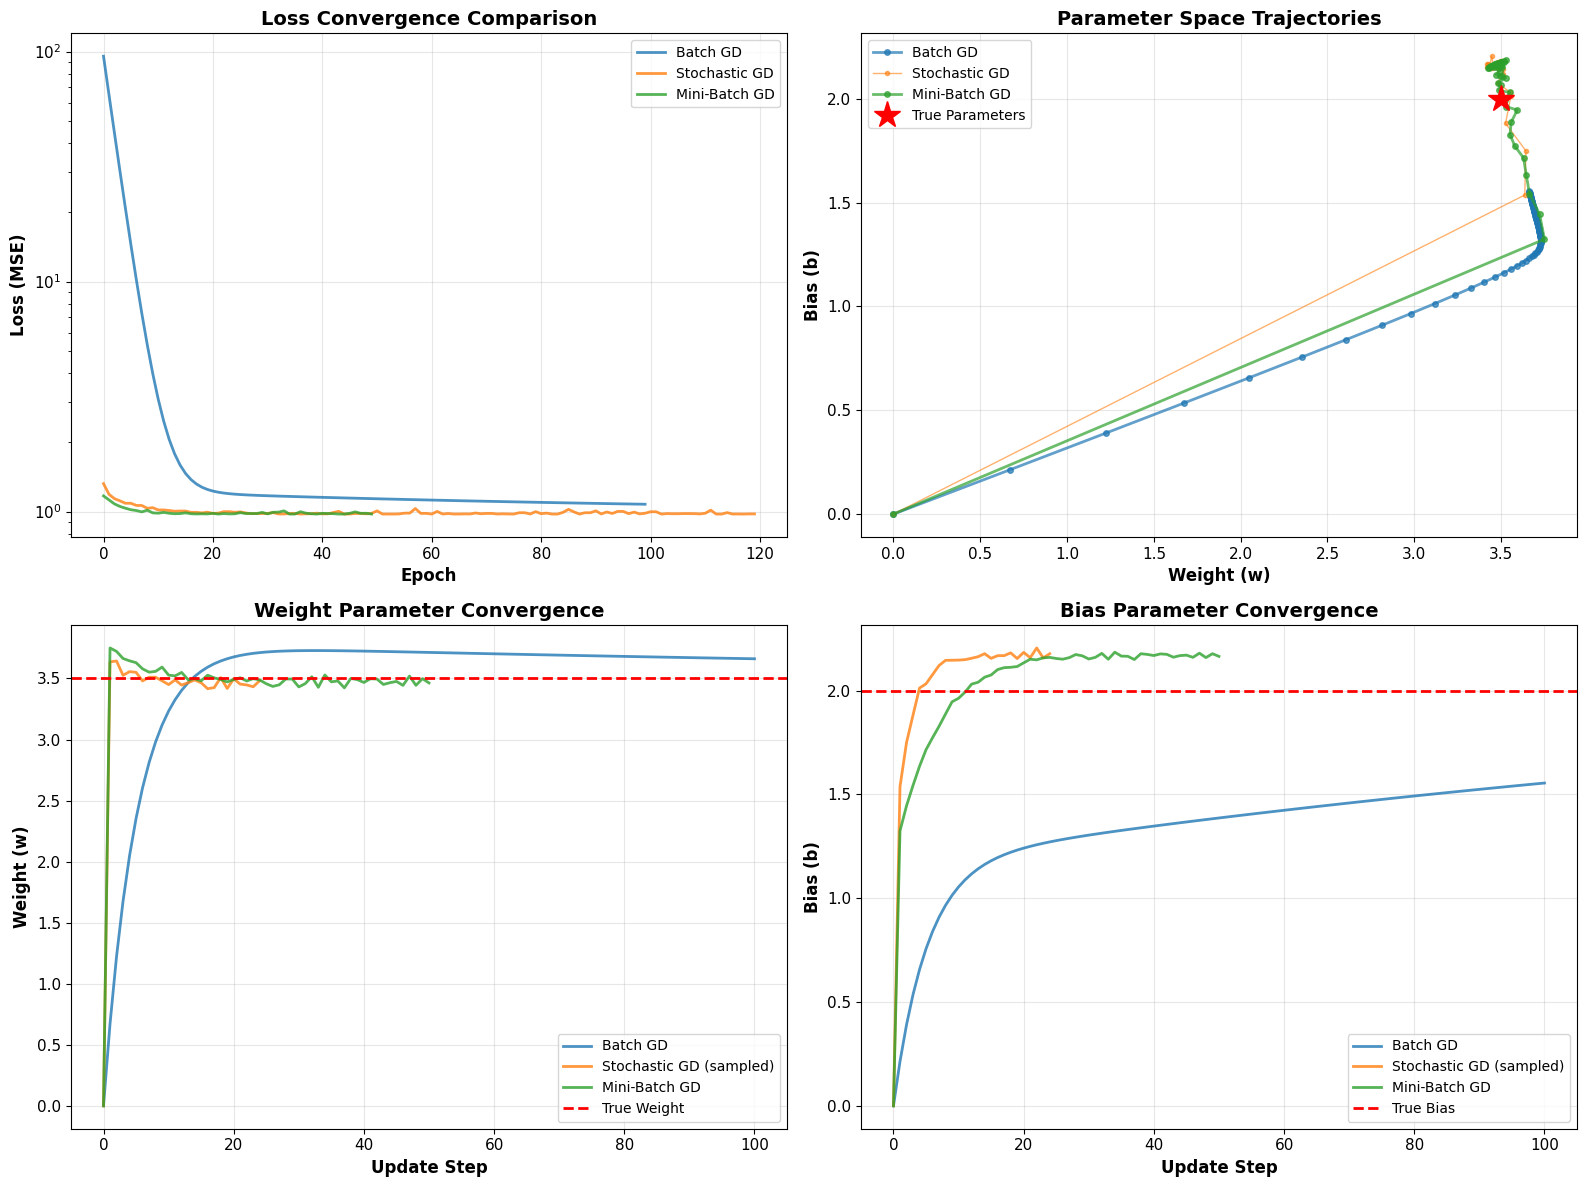


Key Observations:
1. Batch GD: Smooth, monotonic decrease in loss
2. Stochastic GD: Noisy convergence with fluctuations
3. Mini-Batch GD: Balanced - smoother than SGD, faster than BGD


In [8]:
# Plot convergence comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Loss curves
ax1 = axes[0, 0]
ax1.plot(bgd_results['loss_history'], label='Batch GD', linewidth=2, alpha=0.8)
ax1.plot(sgd_results['loss_history'], label='Stochastic GD', linewidth=2, alpha=0.8)
ax1.plot(mbgd_results['loss_history'], label='Mini-Batch GD', linewidth=2, alpha=0.8)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss (MSE)', fontweight='bold')
ax1.set_title('Loss Convergence Comparison', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Parameter trajectories in 2D space
ax2 = axes[0, 1]
ax2.plot(bgd_results['w_history'], bgd_results['b_history'], 'o-',
         label='Batch GD', linewidth=2, markersize=4, alpha=0.7)
ax2.plot(sgd_results['w_history'][::5], sgd_results['b_history'][::5], 'o-',
         label='Stochastic GD', linewidth=1, markersize=3, alpha=0.6)
ax2.plot(mbgd_results['w_history'], mbgd_results['b_history'], 'o-',
         label='Mini-Batch GD', linewidth=2, markersize=4, alpha=0.7)
ax2.plot(TRUE_WEIGHT, TRUE_BIAS, 'r*', markersize=20, label='True Parameters', zorder=10)
ax2.set_xlabel('Weight (w)', fontweight='bold')
ax2.set_ylabel('Bias (b)', fontweight='bold')
ax2.set_title('Parameter Space Trajectories', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Weight convergence
ax3 = axes[1, 0]
ax3.plot(bgd_results['w_history'], label='Batch GD', linewidth=2, alpha=0.8)
ax3.plot(sgd_results['w_history'][::5], label='Stochastic GD (sampled)', linewidth=2, alpha=0.8)
ax3.plot(mbgd_results['w_history'], label='Mini-Batch GD', linewidth=2, alpha=0.8)
ax3.axhline(TRUE_WEIGHT, color='red', linestyle='--', linewidth=2, label='True Weight')
ax3.set_xlabel('Update Step', fontweight='bold')
ax3.set_ylabel('Weight (w)', fontweight='bold')
ax3.set_title('Weight Parameter Convergence', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Bias convergence
ax4 = axes[1, 1]
ax4.plot(bgd_results['b_history'], label='Batch GD', linewidth=2, alpha=0.8)
ax4.plot(sgd_results['b_history'][::5], label='Stochastic GD (sampled)', linewidth=2, alpha=0.8)
ax4.plot(mbgd_results['b_history'], label='Mini-Batch GD', linewidth=2, alpha=0.8)
ax4.axhline(TRUE_BIAS, color='red', linestyle='--', linewidth=2, label='True Bias')
ax4.set_xlabel('Update Step', fontweight='bold')
ax4.set_ylabel('Bias (b)', fontweight='bold')
ax4.set_title('Bias Parameter Convergence', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("=" * 70)
print("1. Batch GD: Smooth, monotonic decrease in loss")
print("2. Stochastic GD: Noisy convergence with fluctuations")
print("3. Mini-Batch GD: Balanced - smoother than SGD, faster than BGD")
print("=" * 70)

### **4.2 Quantitative Performance Comparison**

**We now compare the three methods across multiple dimensions: accuracy, speed, and computational efficiency.**

In [9]:
# Comprehensive comparison table
import pandas as pd

comparison_data = {
    'Method': ['Batch GD', 'Stochastic GD', 'Mini-Batch GD'],
    'Final Loss': [
        bgd_results['loss_history'][-1],
        sgd_results['loss_history'][-1],
        mbgd_results['loss_history'][-1]
    ],
    'Final Weight': [
        bgd_results['w'],
        sgd_results['w'],
        mbgd_results['w']
    ],
    'Final Bias': [
        bgd_results['b'],
        sgd_results['b'],
        mbgd_results['b']
    ],
    'Weight Error': [
        abs(bgd_results['w'] - TRUE_WEIGHT),
        abs(sgd_results['w'] - TRUE_WEIGHT),
        abs(mbgd_results['w'] - TRUE_WEIGHT)
    ],
    'Bias Error': [
        abs(bgd_results['b'] - TRUE_BIAS),
        abs(sgd_results['b'] - TRUE_BIAS),
        abs(mbgd_results['b'] - TRUE_BIAS)
    ],
    'Training Time (s)': [
        bgd_results['time'],
        sgd_results['time'],
        mbgd_results['time']
    ],
    'Total Updates': [
        len(bgd_results['loss_history']),
        sgd_results['iterations'],
        mbgd_results['iterations']
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("=" * 100)
print("COMPREHENSIVE PERFORMANCE COMPARISON")
print("=" * 100)
print(df_comparison.to_string(index=False))
print("=" * 100)

# Additional insights
print("\nPerformance Insights:")
print("-" * 100)
print(f"Best Final Loss: {df_comparison.loc[df_comparison['Final Loss'].idxmin(), 'Method']}")
print(f"  → Loss: {df_comparison['Final Loss'].min():.6f}")
print(f"\nFastest Training: {df_comparison.loc[df_comparison['Training Time (s)'].idxmin(), 'Method']}")
print(f"  → Time: {df_comparison['Training Time (s)'].min():.4f} seconds")
print(f"\nBest Weight Recovery: {df_comparison.loc[df_comparison['Weight Error'].idxmin(), 'Method']}")
print(f"  → Error: {df_comparison['Weight Error'].min():.6f}")
print(f"\nBest Bias Recovery: {df_comparison.loc[df_comparison['Bias Error'].idxmin(), 'Method']}")
print(f"  → Error: {df_comparison['Bias Error'].min():.6f}")
print("-" * 100)

# Speedup analysis
bgd_time = bgd_results['time']
print(f"\nSpeedup Analysis (relative to Batch GD):")
print(f"  Stochastic GD: {bgd_time / sgd_results['time']:.2f}x")
print(f"  Mini-Batch GD: {bgd_time / mbgd_results['time']:.2f}x")
print("=" * 100)

COMPREHENSIVE PERFORMANCE COMPARISON
       Method  Final Loss  Final Weight  Final Bias  Weight Error  Bias Error  Training Time (s)  Total Updates
     Batch GD    1.075875      3.661397    1.554799      0.161397    0.445201           0.004807            100
Stochastic GD    0.976589      3.482310    2.177558      0.017690    0.177558           0.417385          20000
Mini-Batch GD    0.975608      3.463374    2.164758      0.036626    0.164758           0.038083           1600

Performance Insights:
----------------------------------------------------------------------------------------------------
Best Final Loss: Mini-Batch GD
  → Loss: 0.975608

Fastest Training: Batch GD
  → Time: 0.0048 seconds

Best Weight Recovery: Stochastic GD
  → Error: 0.017690

Best Bias Recovery: Mini-Batch GD
  → Error: 0.164758
----------------------------------------------------------------------------------------------------

Speedup Analysis (relative to Batch GD):
  Stochastic GD: 0.01x
  Mini-Bat

### **4.3 Impact of Batch Size on Mini-Batch GD**

**The batch size is a critical hyperparameter in Mini-Batch Gradient Descent.** Let's investigate its effect on convergence behavior and computational efficiency.

Batch Size Experiment

Training with batch size = 1
----------------------------------------------------------------------
  Final Loss: 0.991087
  Training Time: 1.2021 seconds
  Parameter Errors: w=0.0822, b=0.1980

Training with batch size = 8
----------------------------------------------------------------------
  Final Loss: 0.978505
  Training Time: 0.1492 seconds
  Parameter Errors: w=0.0494, b=0.1670

Training with batch size = 32
----------------------------------------------------------------------
  Final Loss: 0.981586
  Training Time: 0.0397 seconds
  Parameter Errors: w=0.0035, b=0.1784

Training with batch size = 64
----------------------------------------------------------------------
  Final Loss: 0.975979
  Training Time: 0.0537 seconds
  Parameter Errors: w=0.0152, b=0.1580

Training with batch size = 128
----------------------------------------------------------------------
  Final Loss: 0.980800
  Training Time: 0.0240 seconds
  Parameter Errors: w=0.0186, b=0.0288

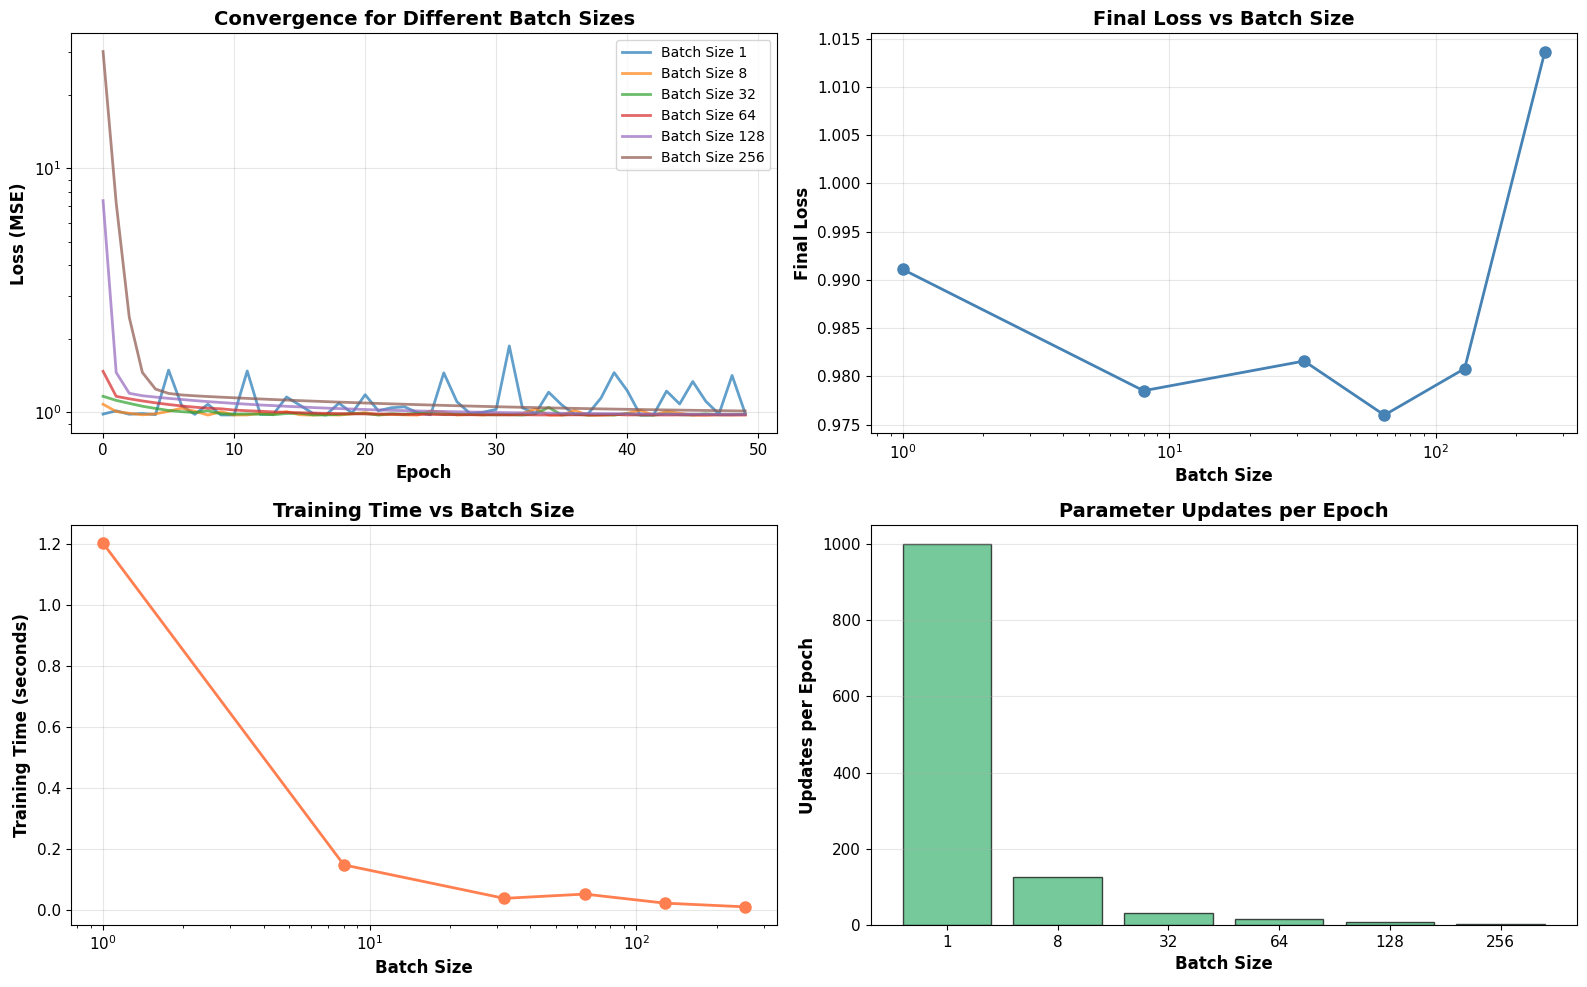


Batch Size Trade-offs:
Small Batches (1-32):
  ✓ More frequent updates
  ✓ Better generalization (more noise can help escape local minima)
  ✗ Slower per-epoch time (more iterations)
  ✗ Noisier gradients

Large Batches (128-256):
  ✓ Faster per-epoch time (fewer iterations)
  ✓ More stable gradients
  ✓ Better hardware utilization (GPUs)
  ✗ May converge to sharp minima (worse generalization)
  ✗ Requires more memory


In [10]:
# Experiment with different batch sizes
batch_sizes = [1, 8, 32, 64, 128, 256]
batch_results = {}

print("Batch Size Experiment")
print("=" * 70)

for bs in batch_sizes:
    print(f"\nTraining with batch size = {bs}")
    print("-" * 70)

    result = mini_batch_gradient_descent(
        X, y,
        learning_rate=0.01,
        epochs=50,
        batch_size=bs,
        initial_w=0.0,
        initial_b=0.0,
        verbose=False
    )

    batch_results[bs] = result

    print(f"  Final Loss: {result['loss_history'][-1]:.6f}")
    print(f"  Training Time: {result['time']:.4f} seconds")
    print(f"  Parameter Errors: w={abs(result['w'] - TRUE_WEIGHT):.4f}, b={abs(result['b'] - TRUE_BIAS):.4f}")

print("=" * 70)

# Visualize batch size impact
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Loss curves for different batch sizes
ax1 = axes[0, 0]
for bs, result in batch_results.items():
    ax1.plot(result['loss_history'], label=f'Batch Size {bs}', linewidth=2, alpha=0.7)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss (MSE)', fontweight='bold')
ax1.set_title('Convergence for Different Batch Sizes', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Final loss vs batch size
ax2 = axes[0, 1]
final_losses = [result['loss_history'][-1] for result in batch_results.values()]
ax2.plot(batch_sizes, final_losses, 'o-', linewidth=2, markersize=8, color='steelblue')
ax2.set_xlabel('Batch Size', fontweight='bold')
ax2.set_ylabel('Final Loss', fontweight='bold')
ax2.set_title('Final Loss vs Batch Size', fontweight='bold', fontsize=14)
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

# Plot 3: Training time vs batch size
ax3 = axes[1, 0]
times = [result['time'] for result in batch_results.values()]
ax3.plot(batch_sizes, times, 'o-', linewidth=2, markersize=8, color='coral')
ax3.set_xlabel('Batch Size', fontweight='bold')
ax3.set_ylabel('Training Time (seconds)', fontweight='bold')
ax3.set_title('Training Time vs Batch Size', fontweight='bold', fontsize=14)
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)

# Plot 4: Updates per epoch vs batch size
ax4 = axes[1, 1]
updates_per_epoch = [N_SAMPLES // bs for bs in batch_sizes]
ax4.bar(range(len(batch_sizes)), updates_per_epoch, color='mediumseagreen', alpha=0.7, edgecolor='black')
ax4.set_xticks(range(len(batch_sizes)))
ax4.set_xticklabels([str(bs) for bs in batch_sizes])
ax4.set_xlabel('Batch Size', fontweight='bold')
ax4.set_ylabel('Updates per Epoch', fontweight='bold')
ax4.set_title('Parameter Updates per Epoch', fontweight='bold', fontsize=14)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nBatch Size Trade-offs:")
print("=" * 70)
print("Small Batches (1-32):")
print("  ✓ More frequent updates")
print("  ✓ Better generalization (more noise can help escape local minima)")
print("  ✗ Slower per-epoch time (more iterations)")
print("  ✗ Noisier gradients")
print("\nLarge Batches (128-256):")
print("  ✓ Faster per-epoch time (fewer iterations)")
print("  ✓ More stable gradients")
print("  ✓ Better hardware utilization (GPUs)")
print("  ✗ May converge to sharp minima (worse generalization)")
print("  ✗ Requires more memory")
print("=" * 70)

### **4.4 Learning Rate Sensitivity Analysis**

**The learning rate is the most critical hyperparameter in gradient descent.** Too small, and convergence is slow; too large, and the algorithm may diverge or oscillate.

Learning Rate Sensitivity Analysis

Training with learning rate = 0.0001
----------------------------------------------------------------------
  ✓ Final Loss: 98.858385
  ✓ Final w: 0.6154, b: 0.1962

Training with learning rate = 0.001
----------------------------------------------------------------------
  ✓ Final Loss: 5.052922
  ✓ Final w: 3.1382, b: 1.0250

Training with learning rate = 0.01
----------------------------------------------------------------------
  ✓ Final Loss: 1.075875
  ✓ Final w: 3.6614, b: 1.5548

Training with learning rate = 0.05
----------------------------------------------------------------------
  ✓ Final Loss: 0.977036
  ✓ Final w: 3.4966, b: 2.0860

Training with learning rate = 0.1
----------------------------------------------------------------------
  ✓ Final Loss: 0.974982
  ✓ Final w: 3.4713, b: 2.1674


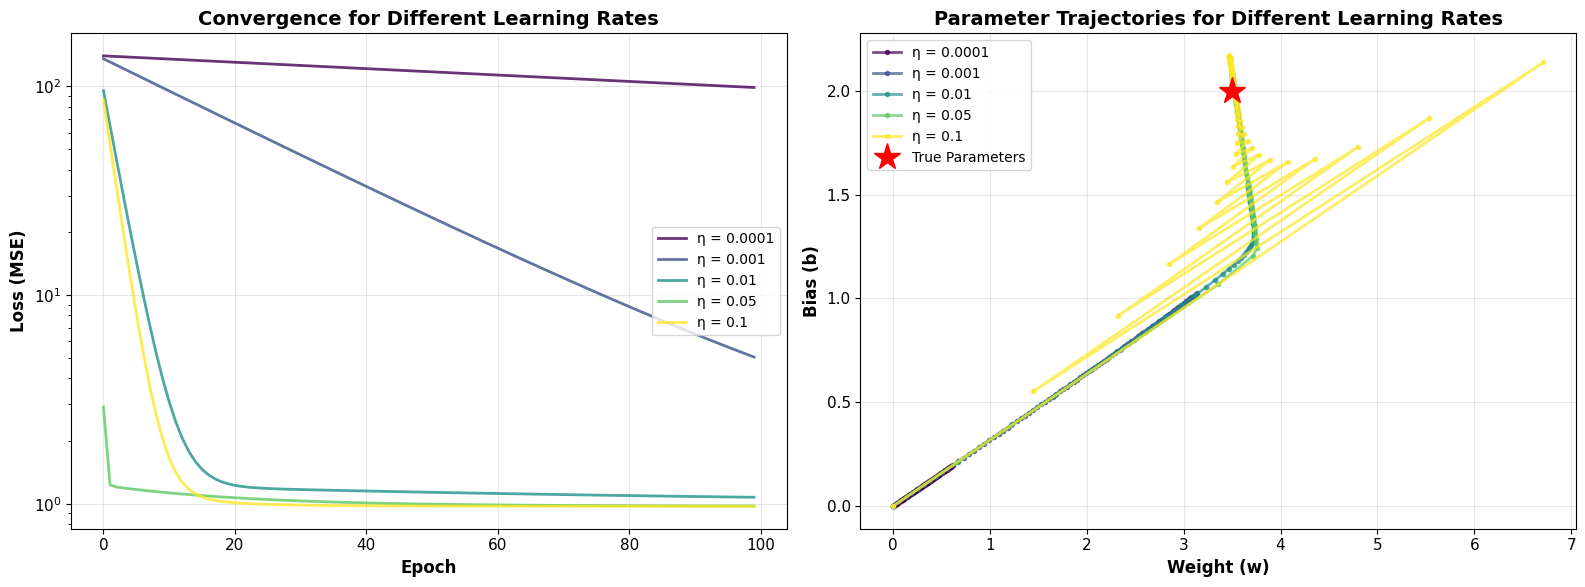


Learning Rate Guidelines:
Too Small (< 0.001):
  • Very slow convergence
  • Requires many iterations
  • May get stuck in plateaus

Optimal Range (0.001 - 0.01):
  • Steady, reliable convergence
  • Good balance of speed and stability
  • Recommended starting point

Too Large (> 0.1):
  • Oscillation around minimum
  • Possible divergence
  • Unstable training


In [11]:
# Experiment with different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1]
lr_results = {}

print("Learning Rate Sensitivity Analysis")
print("=" * 70)

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")
    print("-" * 70)

    try:
        result = batch_gradient_descent(
            X, y,
            learning_rate=lr,
            epochs=100,
            initial_w=0.0,
            initial_b=0.0,
            verbose=False
        )

        lr_results[lr] = result

        print(f"  ✓ Final Loss: {result['loss_history'][-1]:.6f}")
        print(f"  ✓ Final w: {result['w']:.4f}, b: {result['b']:.4f}")

    except Exception as e:
        print(f"  ✗ Training failed: {str(e)}")
        lr_results[lr] = None

print("=" * 70)

# Visualize learning rate impact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss curves for different learning rates
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates)))
for (lr, result), color in zip(lr_results.items(), colors):
    if result is not None:
        ax1.plot(result['loss_history'], label=f'η = {lr}', linewidth=2, alpha=0.8, color=color)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss (MSE)', fontweight='bold')
ax1.set_title('Convergence for Different Learning Rates', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Parameter trajectories for different learning rates
ax2 = axes[1]
for (lr, result), color in zip(lr_results.items(), colors):
    if result is not None:
        ax2.plot(result['w_history'], result['b_history'], 'o-',
                label=f'η = {lr}', linewidth=2, markersize=3, alpha=0.7, color=color)
ax2.plot(TRUE_WEIGHT, TRUE_BIAS, 'r*', markersize=20, label='True Parameters', zorder=10)
ax2.set_xlabel('Weight (w)', fontweight='bold')
ax2.set_ylabel('Bias (b)', fontweight='bold')
ax2.set_title('Parameter Trajectories for Different Learning Rates', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLearning Rate Guidelines:")
print("=" * 70)
print("Too Small (< 0.001):")
print("  • Very slow convergence")
print("  • Requires many iterations")
print("  • May get stuck in plateaus")
print("\nOptimal Range (0.001 - 0.01):")
print("  • Steady, reliable convergence")
print("  • Good balance of speed and stability")
print("  • Recommended starting point")
print("\nToo Large (> 0.1):")
print("  • Oscillation around minimum")
print("  • Possible divergence")
print("  • Unstable training")
print("=" * 70)

## **5. Integration with PyTorch**

### **5.1 Theoretical Connection**

**PyTorch implements gradient descent optimization through its `torch.optim` module.** Understanding the relationship between our manual implementations and PyTorch's optimizers is crucial for practical deep learning.

#### **5.1.1 PyTorch Optimizer Architecture**

PyTorch provides several optimizers that implement different gradient descent variants:

| **PyTorch Optimizer** | **Corresponds To** | **Key Differences** |
|---------------------|-------------------|-------------------|
| `torch.optim.SGD` | All three variants | Batch size controlled by DataLoader |

#### **5.1.2 Key Concepts**

**Important:** In PyTorch terminology, "SGD" refers to the optimization algorithm, but the batch size (and thus whether it's truly stochastic, mini-batch, or batch) is determined by the DataLoader configuration:

- **Batch GD in PyTorch**: `batch_size = len(dataset)`
- **SGD in PyTorch**: `batch_size = 1`
- **Mini-Batch GD in PyTorch**: `batch_size = 32, 64, 128, etc.`

### **5.2 PyTorch Implementation**

**Let's implement the same linear regression problem using PyTorch and compare results with our manual implementations.**

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Check PyTorch version
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print("=" * 70)

PyTorch Version: 2.8.0+cu126
CUDA Available: True


In [13]:
# Convert NumPy arrays to PyTorch tensors
X_torch = torch.from_numpy(X).float()
y_torch = torch.from_numpy(y).float()

# Define Linear Regression Model in PyTorch
class LinearRegressionPyTorch(nn.Module):
    """
    Linear Regression Model using PyTorch's nn.Module.

    Implements: y = w*x + b
    """
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # 1 input feature, 1 output

    def forward(self, x):
        return self.linear(x)


# Initialize model
torch.manual_seed(42)
model_pytorch = LinearRegressionPyTorch()

print("PyTorch Model Architecture:")
print("=" * 70)
print(model_pytorch)
print(f"\nInitial Parameters:")
for name, param in model_pytorch.named_parameters():
    print(f"  {name}: {param.data}")
print("=" * 70)

PyTorch Model Architecture:
LinearRegressionPyTorch(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Initial Parameters:
  linear.weight: tensor([[0.7645]])
  linear.bias: tensor([0.8300])


In [14]:
def train_pytorch_model(model, X, y, batch_size, learning_rate, epochs, optimizer_name='SGD'):
    """
    Train PyTorch model using specified optimizer and batch size.

    Parameters:
    -----------
    model : nn.Module
        PyTorch model
    X, y : torch.Tensor
        Training data
    batch_size : int
        Batch size (determines GD variant)
    learning_rate : float
        Learning rate
    epochs : int
        Number of training epochs
    optimizer_name : str
        Optimizer type ('SGD', 'Adam', etc.)

    Returns:
    --------
    Dict
        Training results
    """
    # Create DataLoader
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Define loss function and optimizer
    loss_fn = nn.MSELoss()

    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # Training loop
    loss_history = []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch_X, batch_y in dataloader:
            # Forward pass
            predictions = model(batch_X)
            loss = loss_fn(predictions, batch_y)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        # Record average loss for epoch
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)

        if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:4d} | Loss: {avg_loss:.6f}")

    training_time = time.time() - start_time

    # Extract final parameters
    weight = model.linear.weight.item()
    bias = model.linear.bias.item()

    return {
        'model': model,
        'loss_history': loss_history,
        'weight': weight,
        'bias': bias,
        'time': training_time
    }


# Train with different configurations
print("\n" + "=" * 70)
print("PYTORCH TRAINING EXPERIMENTS")
print("=" * 70)

# 1. Batch Gradient Descent (batch_size = full dataset)
print("\n1. Batch GD (batch_size = 1000)")
print("-" * 70)
model_bgd = LinearRegressionPyTorch()
torch.manual_seed(42)
pytorch_bgd = train_pytorch_model(model_bgd, X_torch, y_torch,
                                  batch_size=len(X_torch),
                                  learning_rate=0.01,
                                  epochs=100)

# 2. Stochastic Gradient Descent (batch_size = 1)
print("\n2. Stochastic GD (batch_size = 1)")
print("-" * 70)
model_sgd = LinearRegressionPyTorch()
torch.manual_seed(42)
pytorch_sgd = train_pytorch_model(model_sgd, X_torch, y_torch,
                                  batch_size=1,
                                  learning_rate=0.001,
                                  epochs=20)

# 3. Mini-Batch Gradient Descent (batch_size = 32)
print("\n3. Mini-Batch GD (batch_size = 32)")
print("-" * 70)
model_mbgd = LinearRegressionPyTorch()
torch.manual_seed(42)
pytorch_mbgd = train_pytorch_model(model_mbgd, X_torch, y_torch,
                                   batch_size=32,
                                   learning_rate=0.01,
                                   epochs=50)

print("\n" + "=" * 70)


PYTORCH TRAINING EXPERIMENTS

1. Batch GD (batch_size = 1000)
----------------------------------------------------------------------
Epoch    0 | Loss: 136.999573
Epoch   10 | Loss: 3.674236
Epoch   20 | Loss: 1.030514
Epoch   30 | Loss: 0.977910
Epoch   40 | Loss: 0.976698
Epoch   50 | Loss: 0.976521
Epoch   60 | Loss: 0.976379
Epoch   70 | Loss: 0.976249
Epoch   80 | Loss: 0.976132
Epoch   90 | Loss: 0.976026
Epoch   99 | Loss: 0.975938

2. Stochastic GD (batch_size = 1)
----------------------------------------------------------------------
Epoch    0 | Loss: 5.098510
Epoch    2 | Loss: 0.987033
Epoch    4 | Loss: 0.979507
Epoch    6 | Loss: 0.989443
Epoch    8 | Loss: 0.987582
Epoch   10 | Loss: 0.986696
Epoch   12 | Loss: 0.987211
Epoch   14 | Loss: 0.986631
Epoch   16 | Loss: 0.987369
Epoch   18 | Loss: 0.989099
Epoch   19 | Loss: 0.989582

3. Mini-Batch GD (batch_size = 32)
----------------------------------------------------------------------
Epoch    0 | Loss: 20.141619
Epoch 

### **5.3 Comparison: Manual vs PyTorch Implementation**

**Let's compare our manual implementations with PyTorch's optimized versions.**

MANUAL IMPLEMENTATION vs PYTORCH COMPARISON
               Method  Final Weight  Final Bias  Final Loss  Training Time (s)
      Manual Batch GD      3.661397    1.554799    1.075875           0.004807
     PyTorch Batch GD      3.487812    2.114285    0.975938           0.790823
           Manual SGD      3.482310    2.177558    0.976589           0.417385
          PyTorch SGD      3.458223    2.173982    0.989582           8.552589
 Manual Mini-Batch GD      3.463374    2.164758    0.975608           0.038083
PyTorch Mini-Batch GD      3.497458    2.186925    0.977045           0.955881


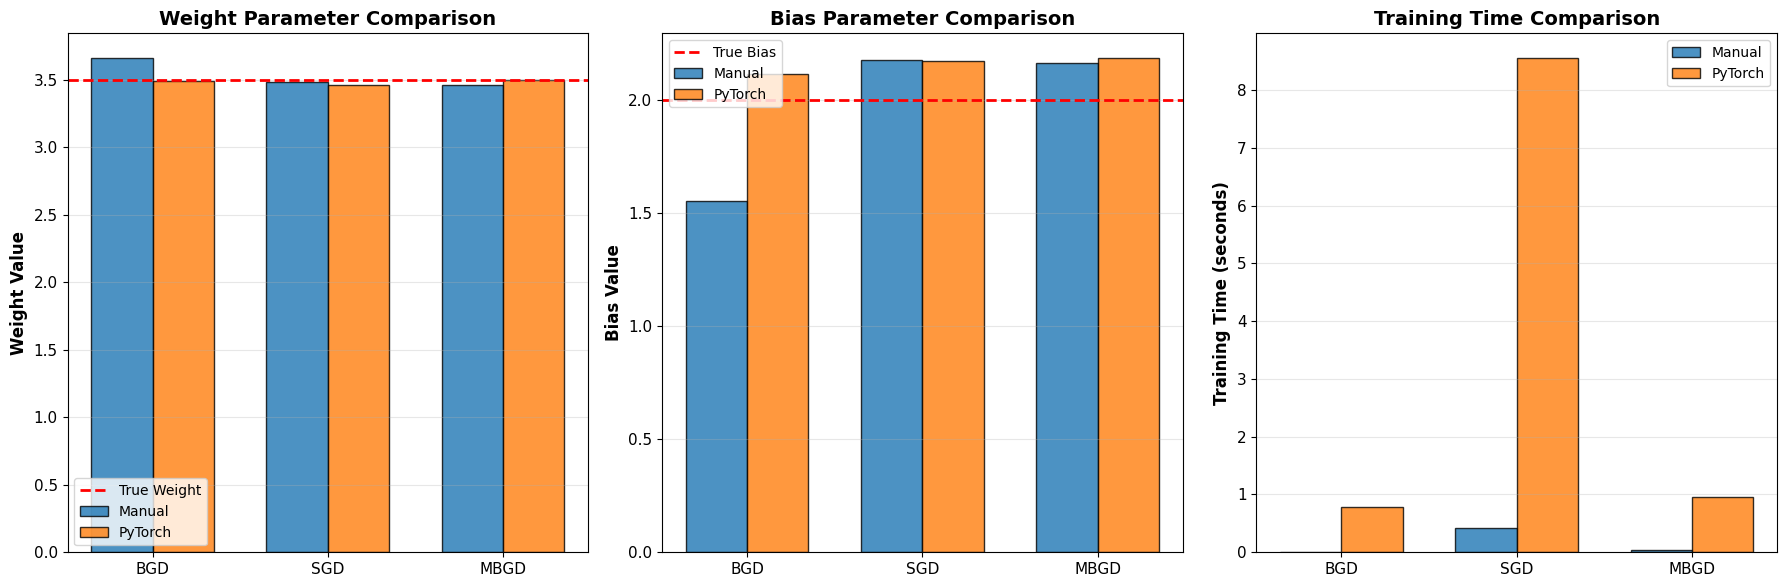

In [15]:
# Create comprehensive comparison
comparison_data = {
    'Method': [
        'Manual Batch GD',
        'PyTorch Batch GD',
        'Manual SGD',
        'PyTorch SGD',
        'Manual Mini-Batch GD',
        'PyTorch Mini-Batch GD'
    ],
    'Final Weight': [
        bgd_results['w'],
        pytorch_bgd['weight'],
        sgd_results['w'],
        pytorch_sgd['weight'],
        mbgd_results['w'],
        pytorch_mbgd['weight']
    ],
    'Final Bias': [
        bgd_results['b'],
        pytorch_bgd['bias'],
        sgd_results['b'],
        pytorch_sgd['bias'],
        mbgd_results['b'],
        pytorch_mbgd['bias']
    ],
    'Final Loss': [
        bgd_results['loss_history'][-1],
        pytorch_bgd['loss_history'][-1],
        sgd_results['loss_history'][-1],
        pytorch_sgd['loss_history'][-1],
        mbgd_results['loss_history'][-1],
        pytorch_mbgd['loss_history'][-1]
    ],
    'Training Time (s)': [
        bgd_results['time'],
        pytorch_bgd['time'],
        sgd_results['time'],
        pytorch_sgd['time'],
        mbgd_results['time'],
        pytorch_mbgd['time']
    ]
}

df_full_comparison = pd.DataFrame(comparison_data)

print("=" * 100)
print("MANUAL IMPLEMENTATION vs PYTORCH COMPARISON")
print("=" * 100)
print(df_full_comparison.to_string(index=False))
print("=" * 100)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Weight comparison
ax1 = axes[0]
methods = ['BGD', 'SGD', 'MBGD']
manual_weights = [bgd_results['w'], sgd_results['w'], mbgd_results['w']]
pytorch_weights = [pytorch_bgd['weight'], pytorch_sgd['weight'], pytorch_mbgd['weight']]

x_pos = np.arange(len(methods))
width = 0.35

ax1.bar(x_pos - width/2, manual_weights, width, label='Manual', alpha=0.8, edgecolor='black')
ax1.bar(x_pos + width/2, pytorch_weights, width, label='PyTorch', alpha=0.8, edgecolor='black')
ax1.axhline(TRUE_WEIGHT, color='red', linestyle='--', linewidth=2, label='True Weight')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(methods)
ax1.set_ylabel('Weight Value', fontweight='bold')
ax1.set_title('Weight Parameter Comparison', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Bias comparison
ax2 = axes[1]
manual_biases = [bgd_results['b'], sgd_results['b'], mbgd_results['b']]
pytorch_biases = [pytorch_bgd['bias'], pytorch_sgd['bias'], pytorch_mbgd['bias']]

ax2.bar(x_pos - width/2, manual_biases, width, label='Manual', alpha=0.8, edgecolor='black')
ax2.bar(x_pos + width/2, pytorch_biases, width, label='PyTorch', alpha=0.8, edgecolor='black')
ax2.axhline(TRUE_BIAS, color='red', linestyle='--', linewidth=2, label='True Bias')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(methods)
ax2.set_ylabel('Bias Value', fontweight='bold')
ax2.set_title('Bias Parameter Comparison', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Training time comparison
ax3 = axes[2]
manual_times = [bgd_results['time'], sgd_results['time'], mbgd_results['time']]
pytorch_times = [pytorch_bgd['time'], pytorch_sgd['time'], pytorch_mbgd['time']]

ax3.bar(x_pos - width/2, manual_times, width, label='Manual', alpha=0.8, edgecolor='black')
ax3.bar(x_pos + width/2, pytorch_times, width, label='PyTorch', alpha=0.8, edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(methods)
ax3.set_ylabel('Training Time (seconds)', fontweight='bold')
ax3.set_title('Training Time Comparison', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## **6. Summary and Best Practices**

### **6.1 Comprehensive Summary**

| **Concept** | **Key Takeaway** |
|-------------|------------------|
| **Gradient Descent** | Iterative optimization using first-order derivatives to minimize loss functions |
| **Batch GD** | Uses entire dataset per update - accurate but slow |
| **Stochastic GD** | Uses single sample per update - fast but noisy |
| **Mini-Batch GD** | Uses small batches per update - optimal balance for most applications |
| **Learning Rate** | Critical hyperparameter controlling convergence speed and stability |
| **Batch Size** | Controls gradient quality vs. computational efficiency trade-off |

#### **6.1.1 Practical Implementation Skills**

✓ **Manual Implementation**: Built gradient descent algorithms from scratch using NumPy  
✓ **PyTorch Integration**: Leveraged PyTorch's optimized optimizers and automatic differentiation  
✓ **Hyperparameter Tuning**: Analyzed effects of learning rate and batch size on convergence  
✓ **Performance Analysis**: Compared methods across accuracy, speed, and memory dimensions  
✓ **Visualization**: Created comprehensive plots to understand optimization dynamics

### **6.2 Best Practices and Recommendations**

#### **6.2.1 Hyperparameter Selection Guidelines**

**Learning Rate:**
- **Starting Point**: 0.001 to 0.01 for most problems
- **Too Small**: Slow convergence, may get stuck
- **Too Large**: Oscillation, divergence, instability
- **Strategy**: Start large and decay over time (learning rate scheduling)

**Batch Size:**
- **Small Models**: 32-64
- **Large Models**: 128-256
- **GPU Memory Limited**: Reduce batch size, use gradient accumulation
- **Rule of Thumb**: Larger batch sizes need larger learning rates

#### **6.2.2 Common Pitfalls to Avoid**

❌ **Don't:**
- Use Batch GD for large datasets (> 100K samples)
- Set learning rate too high without monitoring
- Use batch size of 1 without good reason (very noisy)
- Forget to shuffle data before each epoch
- Compare methods with different numbers of epochs

✅ **Do:**
- Monitor both training and validation loss
- Use learning rate schedules for long training
- Implement early stopping to prevent overfitting
- Normalize/standardize input features
- Save checkpoints during training